# Loading the dataset

In [ ]:
!wget https://raw.githubusercontent.com/nachikethmurthy/Source-Code-Dataset-for-Machine-Learning-using-Python/main/Data/sentiment_train

--2023-07-31 09:27:52--  https://raw.githubusercontent.com/nachikethmurthy/Source-Code-Dataset-for-Machine-Learning-using-Python/main/Data/sentiment_train
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 447555 (437K) [text/plain]
Saving to: ‘sentiment_train’

sentiment_train     100%[===================>] 437.07K  --.-KB/s    in 0.005s  

2023-07-31 09:27:52 (81.7 MB/s) - ‘sentiment_train’ saved [447555/447555]



In [ ]:
import pandas as pd
import numpy as np
train_df = pd.read_csv('sentiment_train', sep="\t")

In [ ]:
train_df.head()

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,this was the first clive cussler i've ever rea...
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimatly did...


In [ ]:
pd.set_option('max_colwidth',800)
train_df.head()

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,"this was the first clive cussler i've ever read, but even books like Relic, and Da Vinci code were more plausible than this."
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimatly didn't seem to hold it's own.


In [ ]:
train_df[train_df['sentiment']==1].head()

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,"this was the first clive cussler i've ever read, but even books like Relic, and Da Vinci code were more plausible than this."
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimatly didn't seem to hold it's own.


In [ ]:
train_df[train_df['sentiment']==0].head()

,sentiment,text
3943,0,da vinci code was a terrible movie.
3944,0,"Then again, the Da Vinci code is super shitty movie, and it made like 700 million."
3945,0,"The Da Vinci Code comes out tomorrow, which sucks."
3946,0,i thought the da vinci code movie was really boring.
3947,0,"God, Yahoo Games has this truly-awful looking Da Vinci Code-themed skin on it's chessboard right now."


## Exploration of the dataset

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6918 entries, 0 to 6917
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  6918 non-null   int64 
 1   text       6918 non-null   object
dtypes: int64(1), object(1)
memory usage: 108.2+ KB


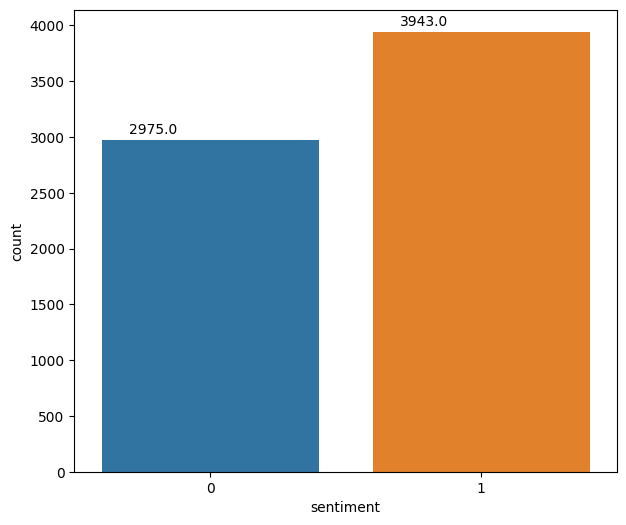

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize =(7,6))

ax = sns.countplot(x='sentiment', data=train_df)
for p in ax.patches:
  ax.annotate(p.get_height(), (p.get_x()+0.1,p.get_height()+50))

# Text preprocessing

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
feature_vector =cv.fit(train_df['text'])

features = cv.get_feature_names_out()
print(f"Total lengh of vocabulary is {len(features)}, examples are {features[:200]}")

Total lengh of vocabulary is 2132, examples are ['00' '007' '10' '10pm' '12' '16' '17' '1984' '1st' '200' '2007' '286'
 '2nd' '30' '31st' '33' '3333' '385' '50' '517' '648' '6th' '700' '7th'
 '8230' '9am' 'aaron' 'able' 'abortion' 'about' 'abrams' 'absolute'
 'absolutely' 'absurd' 'academy' 'acceptable' 'accompaniment' 'according'
 'account' 'achieved' 'aching' 'acne' 'acoustic' 'acting' 'action' 'actor'
 'actors' 'actual' 'actually' 'adaptation' 'add' 'addition' 'admired'
 'admiring' 'adorable' 'adore' 'adult' 'adversity' 'afraid' 'after'
 'afterschool' 'afterwards' 'again' 'against' 'ago' 'agree' 'agreed' 'ah'
 'aimee' 'ain' 'aka' 'al' 'alarm' 'all' 'allegedly' 'allegory' 'almost'
 'along' 'already' 'alright' 'also' 'although' 'altogether' 'always' 'am'
 'amazes' 'amazing' 'amazingly' 'america' 'amã' 'an' 'anatomy' 'anax'
 'and' 'ang' 'angel' 'angels' 'angle' 'animated' 'anime' 'aniwae' 'anne'
 'answers' 'anus' 'any' 'anyhow' 'anyone' 'anything' 'anyway' 'anyways'
 'anywhere' 'ap' 'a

In [ ]:
train_df_features =cv.transform(train_df['text'])

In [ ]:
train_df_features

<6918x2132 sparse matrix of type '<class 'numpy.int64'>'
	with 65398 stored elements in Compressed Sparse Row format>

In [ ]:
train_df_features.getnnz()

65398

In [ ]:
train_df_features.todense()

matrix([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
train_df2 =pd.DataFrame(train_df_features.todense(), columns =features)
train_df2.head()

,00,007,10,10pm,12,16,17,1984,1st,200,...,yip,you,young,younger,your,yuck,yuh,zach,zen,µª
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_df2.iloc[0:2,150:158]

,away,awesome,awesomely,awesomeness,awesomest,awful,awkward,axes
0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0


In [ ]:
train_df.head(2)

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,"this was the first clive cussler i've ever read, but even books like Relic, and Da Vinci code were more plausible than this."


In [ ]:
train_df2[['the','da','vinci','awesome','just','book']][:2]

,the,da,vinci,awesome,just,book
0,1,1,1,1,1,1
1,1,1,1,0,0,0
